# 🛡️ ACIS Insurance Risk Analytics
## Task 1: Exploratory Data Analysis
---
**Author:** Afomia Tadesse  
**Date:** May 2026  
**Dataset:** ACIS Historical Insurance Data (Feb 2014 – Aug 2015)

---

### Project Context

AlphaCare Insurance Solutions (ACIS) wants to move beyond 
intuition-based pricing toward analytics-driven decisions. 
This notebook explores 18 months of historical car insurance 
data to:

- Understand the structure and quality of the data
- Identify key risk drivers across provinces, vehicle types, and gender
- Uncover patterns in premiums, claims, and profitability
- Lay the groundwork for hypothesis testing and predictive modeling

### Two Core Metrics

| Metric | Formula | Meaning |
|---|---|---|
| **Loss Ratio** | TotalClaims ÷ TotalPremium | > 1 means losing money |
| **Margin** | TotalPremium − TotalClaims | Per-policy profit |

---
## 1. Environment Setup
Importing all required libraries and loading custom utility 
modules from `src/`.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import load_and_prepare

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
print("✅ All imports successful")

✅ All imports successful


---
## 2. Data Loading

The dataset is a pipe-delimited `.txt` file containing 
policy, client, vehicle, and claim information. 

We use our custom `load_and_prepare()` function which:
1. Loads the raw file
2. Fixes column data types
3. Adds derived metrics (LossRatio, Margin)

In [2]:
DATA_PATH = '../data/MachineLearningRating_v3.txt'
df = load_and_prepare(DATA_PATH)

✅ Data loaded successfully: 1,000,098 rows, 52 columns
✅ TransactionMonth converted to datetime
✅ Numeric columns fixed
✅ Columns standardized: ['make', 'kilowatts', 'cubiccapacity', 'bodytype', 'mmcode']
✅ Derived metrics added: LossRatio, Margin


---
## 3. Data Summarization

First look at the dataset — shape, types, and a sample 
of rows to understand what we're working with.

In [3]:
print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)
print(f"Rows:    {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print("\n" + "=" * 60)
print("COLUMN DATA TYPES")
print("=" * 60)
print(df.dtypes)

DATASET SHAPE
Rows:    1,000,098
Columns: 54

COLUMN DATA TYPES
UnderwrittenCoverID                  int64
PolicyID                             int64
TransactionMonth            datetime64[us]
IsVATRegistered                       bool
Citizenship                            str
LegalType                              str
Title                                  str
Language                               str
Bank                                   str
AccountType                            str
MaritalStatus                          str
Gender                                 str
Country                                str
Province                               str
PostalCode                           int64
MainCrestaZone                         str
SubCrestaZone                          str
ItemType                               str
Mmcode                             float64
VehicleType                            str
RegistrationYear                     int64
Make                             

In [4]:
print("FIRST 5 ROWS")
df.head()

FIRST 5 ROWS


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims,LossRatio,Margin
0,145249,12827,2015-03-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,0.0,21.929825
1,145249,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,0.0,21.929825
2,145249,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,NaN,0.000000
3,145255,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0,0.0,512.848070
4,145255,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,NaN,0.000000


In [5]:
key_cols = ['TotalPremium', 'TotalClaims', 'SumInsured',
            'LossRatio', 'Margin', 'CustomValueEstimate']

print("DESCRIPTIVE STATISTICS — KEY FINANCIAL COLUMNS")
df[key_cols].describe().round(2)

DESCRIPTIVE STATISTICS — KEY FINANCIAL COLUMNS


,TotalPremium,TotalClaims,SumInsured,LossRatio,Margin,CustomValueEstimate
count,1000098.00,1000098.00,1000098.00,618464.00,1000098.00,220456.00
mean,61.91,64.86,604172.73,0.35,-2.96,225531.13
std,230.28,2384.07,1508331.84,9.29,2367.14,564515.75
min,-782.58,-12002.41,0.01,-18.70,-392848.57,20000.00
25%,0.00,0.00,5000.00,0.00,0.00,135000.00
50%,2.18,0.00,7500.00,0.00,2.16,220000.00
75%,21.93,0.00,250000.00,0.00,21.93,280000.00
max,65282.60,393092.11,12636200.00,2553.60,65282.60,26550000.00


### 📝 Observations — Data Summarization

> Fill this in after running the cell above. Example:

- The dataset contains **X rows** and **Y columns**
- `TotalClaims` has a mean of R X but a max of R Y — 
  suggesting heavy right skew and potential outliers
- `LossRatio` mean of X means the portfolio is 
  [profitable / unprofitable] on average
- `TransactionMonth` is correctly typed as datetime ✅

---
## 4. Data Quality Assessment

Checking for missing values, incorrect types, and duplicate 
records. Real insurance data is messy — we need a clear 
strategy for handling gaps before any modeling.

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(f"Columns with missing data: {len(missing_df)} out of {df.shape[1]}")
print()
print(missing_df.to_string())

Columns with missing data: 23 out of 54

                         Missing Count  Missing %
NumberOfVehiclesInFleet        1000098     100.00
CrossBorder                     999400      99.93
CustomValueEstimate             779642      77.96
Rebuilt                         641901      64.18
WrittenOff                      641901      64.18
Converted                       641901      64.18
LossRatio                       381634      38.16
NewVehicle                      153295      15.33
Bank                            145961      14.59
AccountType                      40232       4.02
Gender                            9536       0.95
MaritalStatus                     8259       0.83
Make                               552       0.06
Mmcode                             552       0.06
VehicleType                        552       0.06
VehicleIntroDate                   552       0.06
NumberOfDoors                      552       0.06
Bodytype                           552       0.06
Kilowatts

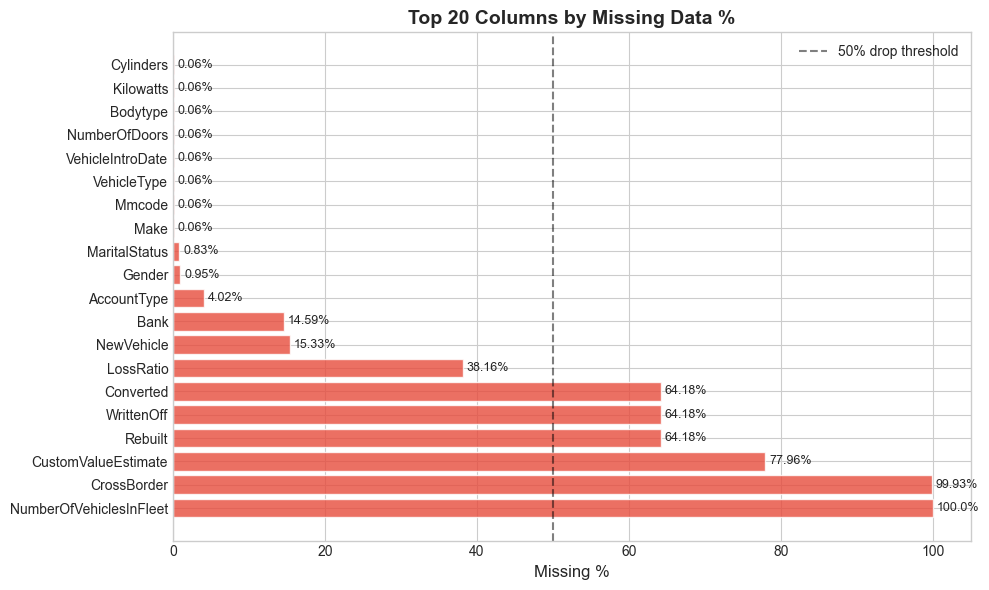

In [7]:
top_missing = missing_df.head(20)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_missing.index, top_missing['Missing %'],
               color='#e74c3c', alpha=0.8, edgecolor='white')

ax.set_xlabel('Missing %', fontsize=12)
ax.set_title('Top 20 Columns by Missing Data %',
             fontsize=14, fontweight='bold')
ax.axvline(x=50, color='black', linestyle='--',
           alpha=0.5, label='50% drop threshold')
ax.legend()

for bar, val in zip(bars, top_missing['Missing %']):
    ax.text(bar.get_width() + 0.5,
            bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

### 📝 Observations — Data Quality

> Fill in after running. Example structure:

**Missing Values Strategy:**

| Column | Missing % | Strategy | Reason |
|---|---|---|---|
| ColumnA | 85% | Drop column | Too much missing |
| ColumnB | 12% | Impute median | Numerical, low missing |
| TotalClaims | X% | Leave as-is | Missing = no claim made |

**Duplicates:** X duplicate rows found — [dropped / kept]

---
## 5. Univariate Analysis

Examining each key variable individually to understand 
its distribution, range, and shape.

**Why this matters:** Insurance claim amounts are almost 
always right-skewed — most policies have small or zero 
claims, but a few have catastrophically large ones. 
Understanding this shape is critical before modeling.

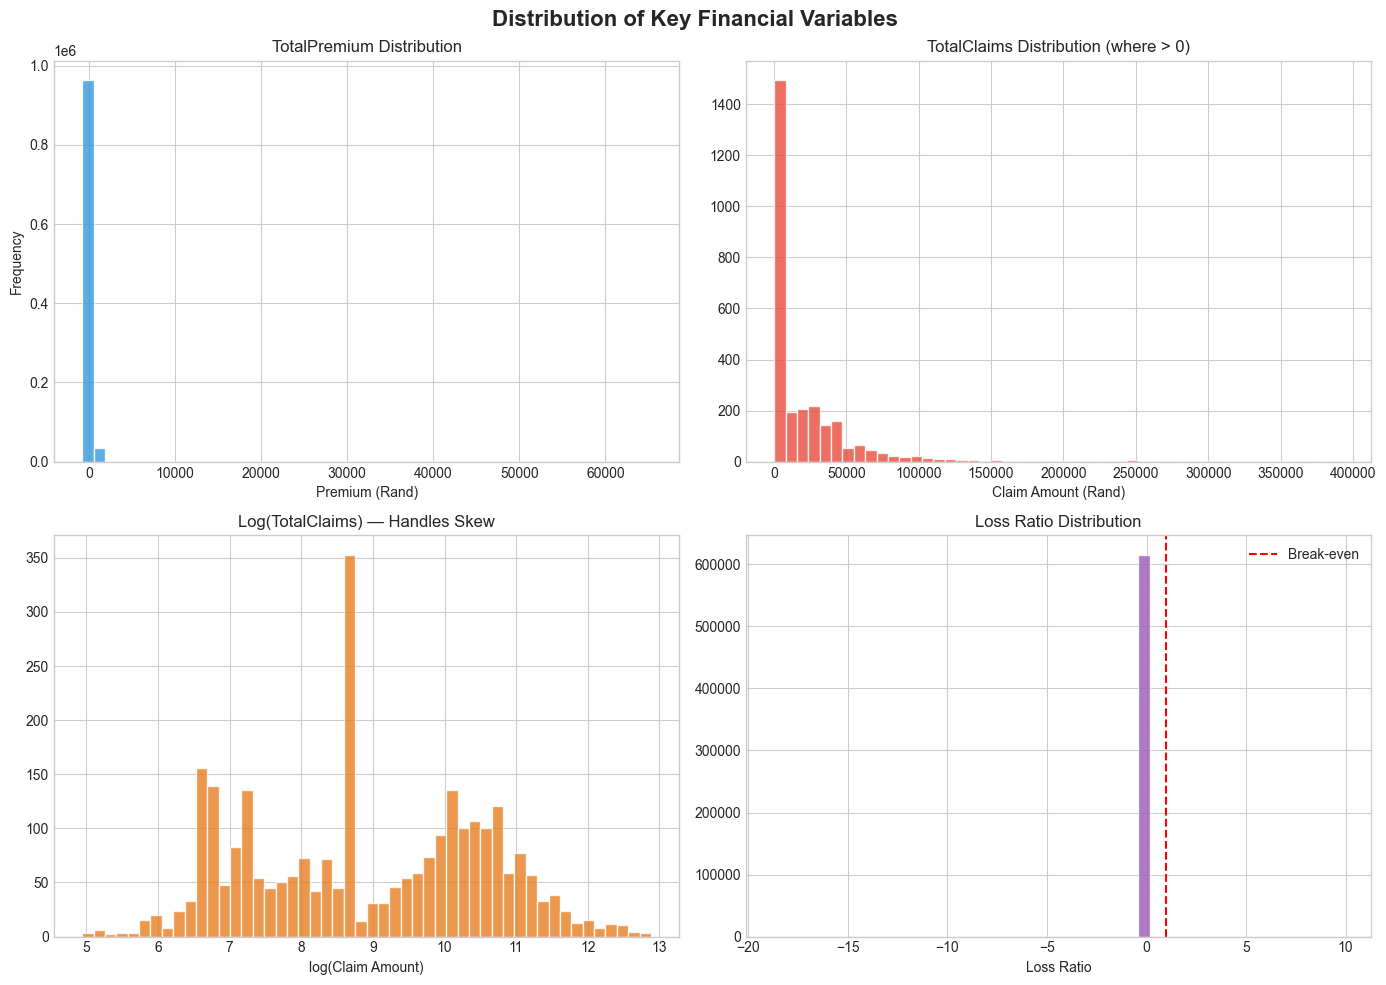

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Key Financial Variables',
             fontsize=16, fontweight='bold')

# TotalPremium
axes[0, 0].hist(df['TotalPremium'].dropna(), bins=50,
                color='#3498db', edgecolor='white', alpha=0.8)
axes[0, 0].set_title('TotalPremium Distribution')
axes[0, 0].set_xlabel('Premium (Rand)')
axes[0, 0].set_ylabel('Frequency')

# TotalClaims (non-zero only)
claims_nonzero = df[df['TotalClaims'] > 0]['TotalClaims']
axes[0, 1].hist(claims_nonzero, bins=50,
                color='#e74c3c', edgecolor='white', alpha=0.8)
axes[0, 1].set_title('TotalClaims Distribution (where > 0)')
axes[0, 1].set_xlabel('Claim Amount (Rand)')

# Log-transformed claims
axes[1, 0].hist(np.log1p(claims_nonzero), bins=50,
                color='#e67e22', edgecolor='white', alpha=0.8)
axes[1, 0].set_title('Log(TotalClaims) — Handles Skew')
axes[1, 0].set_xlabel('log(Claim Amount)')

# Loss Ratio
lr = df['LossRatio'].replace(
    [float('inf'), -float('inf')], float('nan')
).dropna()
lr = lr[lr < 10]
axes[1, 1].hist(lr, bins=50,
                color='#9b59b6', edgecolor='white', alpha=0.8)
axes[1, 1].axvline(x=1.0, color='red',
                   linestyle='--', label='Break-even')
axes[1, 1].set_title('Loss Ratio Distribution')
axes[1, 1].set_xlabel('Loss Ratio')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('../reports/financial_distributions.png',
            dpi=150, bbox_inches='tight')
plt.show()

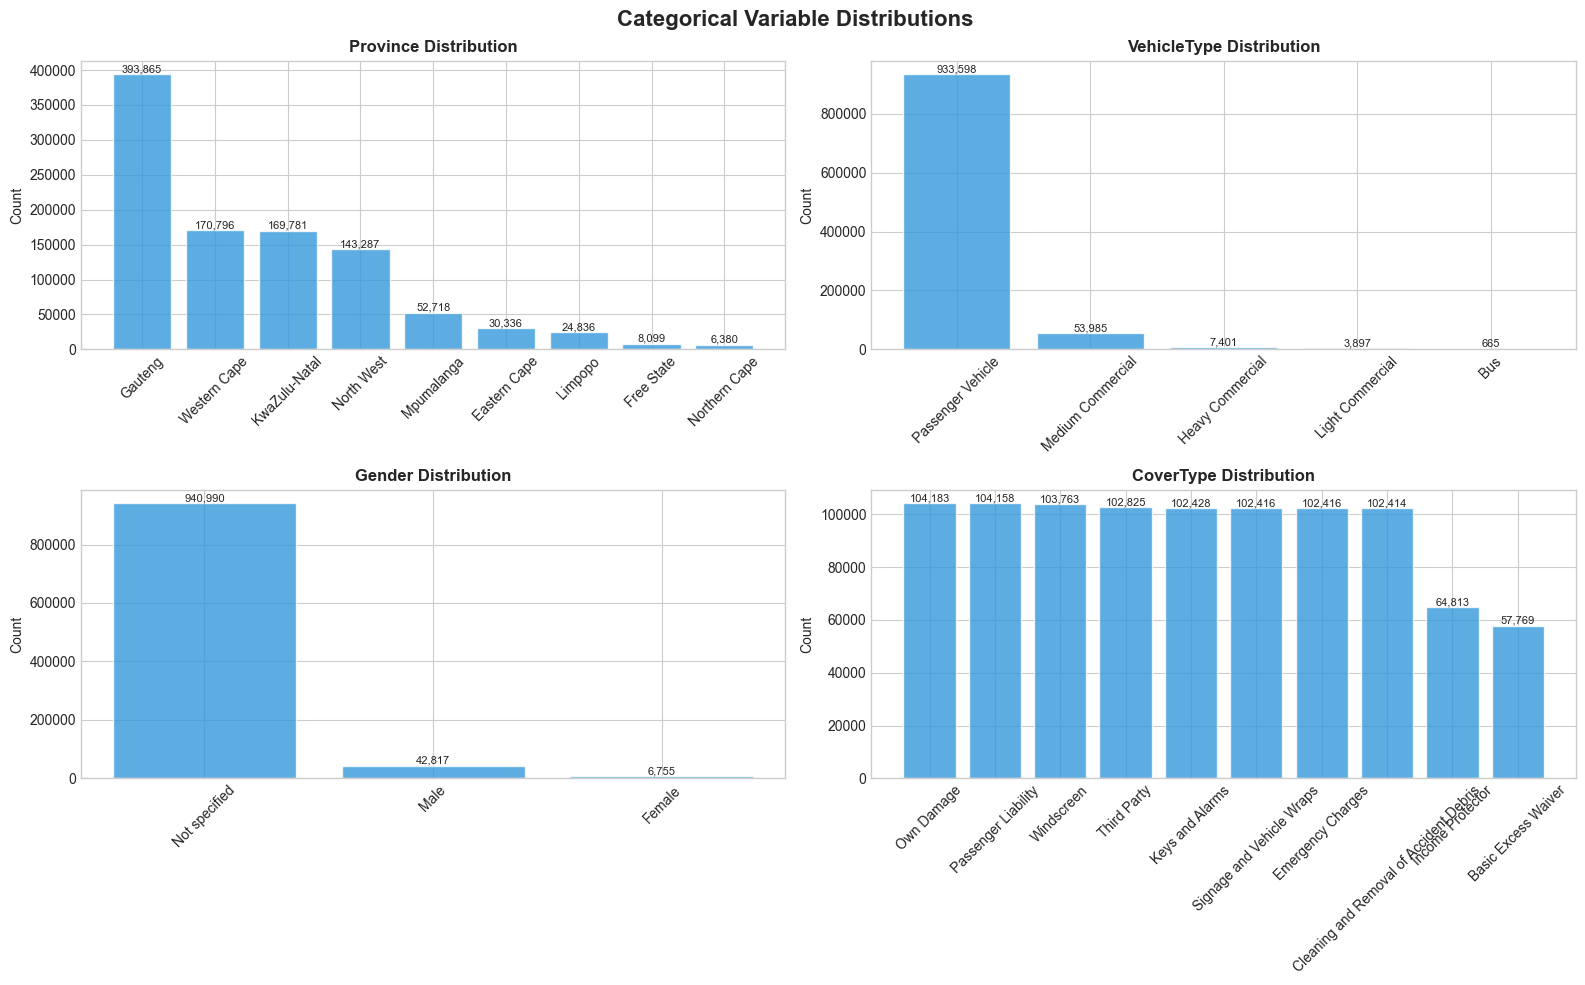

In [9]:
# ─── Bar Charts for Categorical Columns ────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Categorical Variable Distributions',
             fontsize=16, fontweight='bold')

cat_cols = ['Province', 'VehicleType', 'Gender', 'CoverType']

for ax, col in zip(axes.flatten(), cat_cols):
    if col in df.columns:
        # value_counts() counts how many times each
        # unique value appears in the column
        counts = df[col].value_counts().head(10)

        bars = ax.bar(counts.index, counts.values,
                      color='#3498db', alpha=0.8,
                      edgecolor='white')
        ax.set_title(f'{col} Distribution',
                     fontweight='bold')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)

        # add count labels on top of each bar
        for bar, val in zip(bars, counts.values):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.01,
                    f'{val:,}',
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../reports/categorical_distributions.png',
            dpi=150, bbox_inches='tight')
plt.show()

### 📝 Observations — Univariate Analysis

- `TotalClaims` is heavily **right-skewed** as expected in 
  insurance — most claims are small, a few are very large
- Log transformation brings claims closer to a normal 
  distribution — we will use this in modeling (Task 4)
- `LossRatio` is concentrated near 0, meaning most policies 
  had no claim during this period

---
## 6. Portfolio-Level Business Metrics

Before drilling into segments, we establish the 
overall portfolio health. This is the single most 
important number — is ACIS profitable overall?

In [10]:
overall_lr = df['TotalClaims'].sum() / df['TotalPremium'].sum()
overall_margin = df['Margin'].sum()

print("=" * 55)
print("PORTFOLIO HEALTH SUMMARY")
print("=" * 55)
print(f"Total Premium:    R {df['TotalPremium'].sum():>15,.2f}")
print(f"Total Claims:     R {df['TotalClaims'].sum():>15,.2f}")
print(f"Total Margin:     R {overall_margin:>15,.2f}")
print(f"Loss Ratio:           {overall_lr:.4f} ({overall_lr*100:.1f}%)")
print("=" * 55)

status = (
    "HIGHLY PROFITABLE" if overall_lr < 0.6
    else "PROFITABLE" if overall_lr < 1.0
    else "LOSING MONEY"
)
print(f"\n📊 Portfolio Status: {status}")

PORTFOLIO HEALTH SUMMARY
Total Premium:    R   61,911,562.70
Total Claims:     R   64,867,546.17
Total Margin:     R   -2,955,983.47
Loss Ratio:           1.0477 (104.8%)

📊 Portfolio Status: LOSING MONEY


---
## 7. Bivariate Analysis — Risk by Segment

Now we look at how risk varies across key segments:
- **Province** — geographic risk differences
- **VehicleType** — which vehicles drive more claims
- **Gender** — demographic risk patterns

These segments directly feed into Task 3 
(Hypothesis Testing).

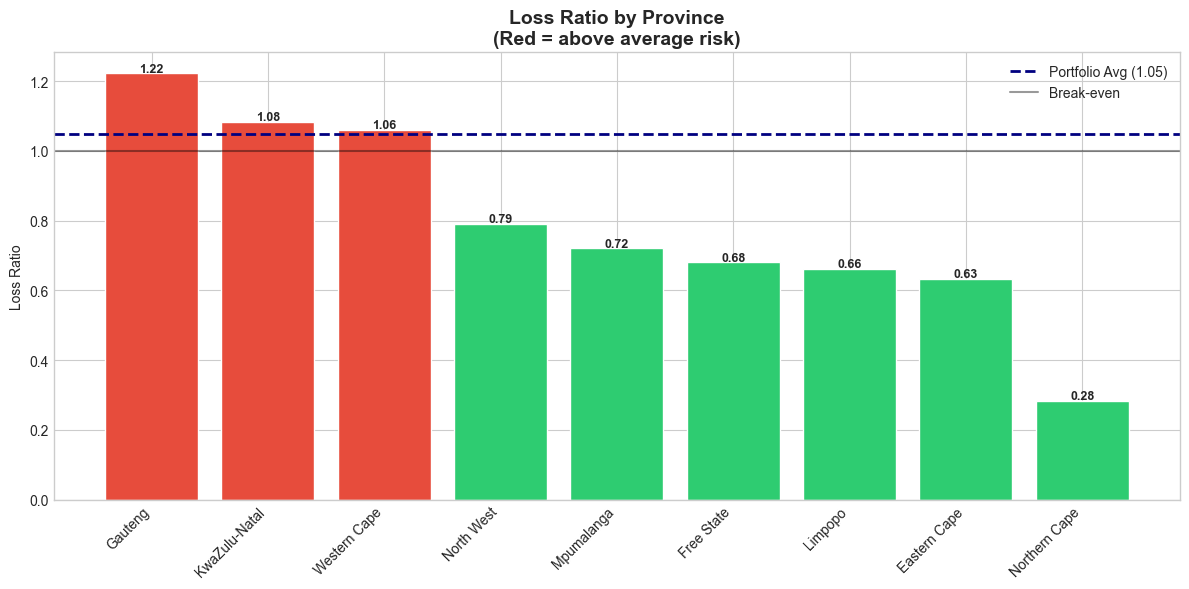

In [11]:
province_metrics = df.groupby('Province').agg(
    TotalPremium=('TotalPremium', 'sum'),
    TotalClaims=('TotalClaims', 'sum'),
    PolicyCount=('PolicyID', 'count')
).reset_index()

province_metrics['LossRatio'] = (
    province_metrics['TotalClaims'] /
    province_metrics['TotalPremium']
)
province_metrics = province_metrics.sort_values(
    'LossRatio', ascending=False
)

fig, ax = plt.subplots(figsize=(12, 6))

colors = [
    '#e74c3c' if lr > overall_lr else '#2ecc71'
    for lr in province_metrics['LossRatio']
]

bars = ax.bar(province_metrics['Province'],
              province_metrics['LossRatio'],
              color=colors, edgecolor='white')

ax.axhline(y=overall_lr, color='navy', linestyle='--',
           linewidth=2,
           label=f'Portfolio Avg ({overall_lr:.2f})')
ax.axhline(y=1.0, color='black', linestyle='-',
           linewidth=1.5, alpha=0.4, label='Break-even')

ax.set_title('Loss Ratio by Province\n'
             '(Red = above average risk)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Loss Ratio')
ax.legend()
plt.xticks(rotation=45, ha='right')

for bar, val in zip(bars, province_metrics['LossRatio']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.2f}', ha='center',
            fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/loss_ratio_by_province.png',
            dpi=150, bbox_inches='tight')
plt.show()

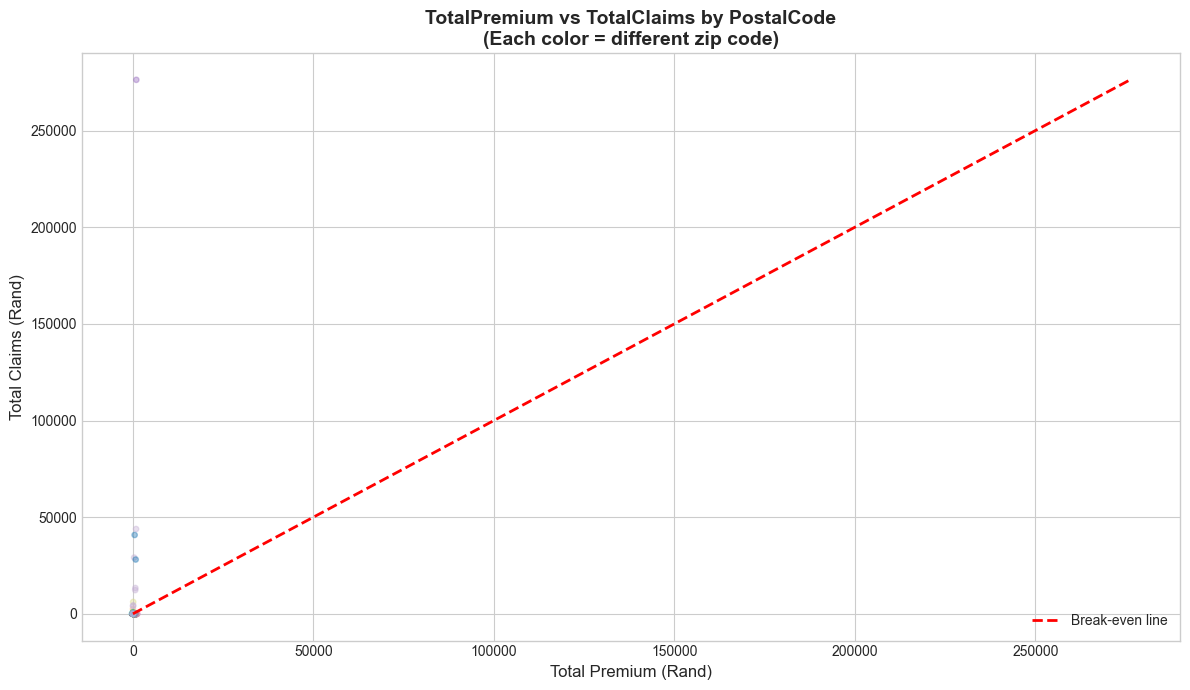

In [12]:
# ─── Scatter: TotalPremium vs TotalClaims by ZipCode ───────

# Sample 5000 rows so the plot isn't too slow/crowded
# with hundreds of thousands of points
sample = df.sample(n=min(5000, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(12, 7))

# scatter plot colored by PostalCode
# we use a sample because plotting 500k dots is slow
scatter = ax.scatter(
    sample['TotalPremium'],       # x axis
    sample['TotalClaims'],        # y axis
    c=sample['PostalCode'].astype('category').cat.codes,
    # .astype('category').cat.codes converts postal codes
    # to numbers so matplotlib can color them
    alpha=0.4,                    # transparency
    cmap='tab20',                 # color map
    s=15                          # dot size
)

ax.set_xlabel('Total Premium (Rand)', fontsize=12)
ax.set_ylabel('Total Claims (Rand)', fontsize=12)
ax.set_title(
    'TotalPremium vs TotalClaims by PostalCode\n'
    '(Each color = different zip code)',
    fontsize=14, fontweight='bold'
)

# Add diagonal break-even line
# where claims = premium (loss ratio = 1)
max_val = max(sample['TotalPremium'].max(),
              sample['TotalClaims'].max())
ax.plot([0, max_val], [0, max_val],
        'r--', linewidth=2, label='Break-even line')
ax.legend()

plt.tight_layout()
plt.savefig('../reports/premium_vs_claims_zipcode.png',
            dpi=150, bbox_inches='tight')
plt.show()

Columns in correlation matrix:
['TotalPremium', 'TotalClaims', 'SumInsured', 'LossRatio', 'Margin', 'CustomValueEstimate', 'Kilowatts', 'Cylinders', 'NumberOfDoors', 'CalculatedPremiumPerTerm', 'RegistrationYear']


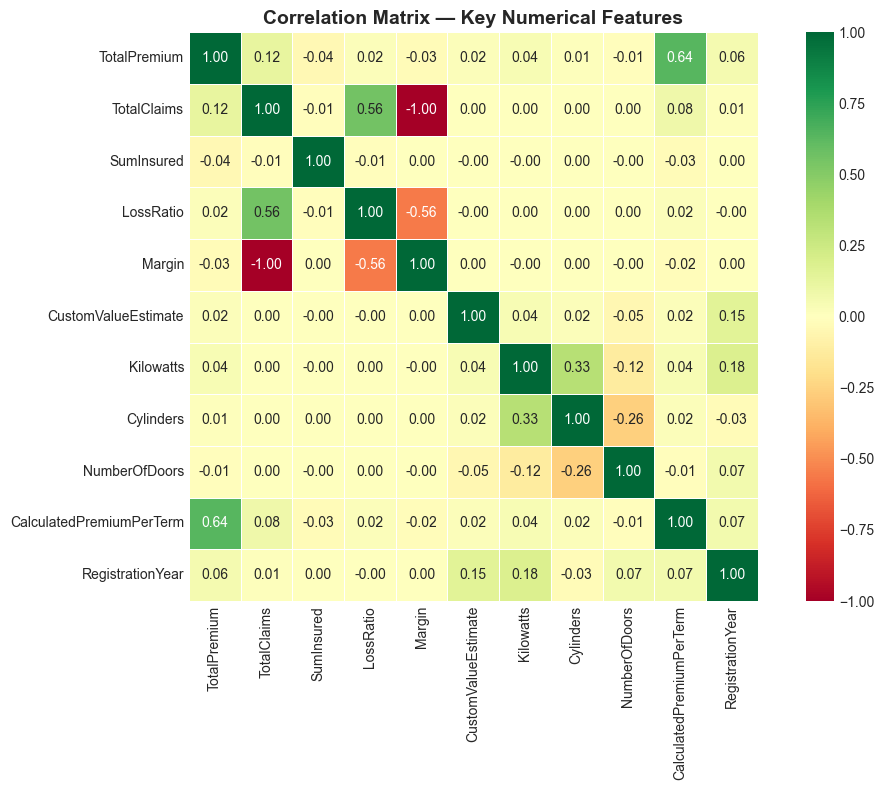

In [18]:
# ─── Correlation Matrix ─────────────────────────────────────

desired_cols = [
    'TotalPremium', 'TotalClaims', 'SumInsured',
    'LossRatio', 'Margin', 'CustomValueEstimate',
    'Kilowatts',              # ← now works after rename
    'Cylinders',              # ← was already correct
    'NumberOfDoors',          # ← was already correct
    'CalculatedPremiumPerTerm',
    'CapitalOutstanding',
    'RegistrationYear'
]

# Safe filter — only use columns that exist and are numeric
num_cols = [
    col for col in desired_cols
    if col in df.columns and
    pd.api.types.is_numeric_dtype(df[col])
]

print("Columns in correlation matrix:")
print(num_cols)

corr_matrix = df[num_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(11, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Correlation Matrix — Key Numerical Features',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/correlation_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

### 📝 Observations — Risk by Province

> Fill in after running. Example:

- **Gauteng** shows the highest Loss Ratio at X.XX — 
  X% above the portfolio average
- **Western Cape** is the most profitable province 
  with a Loss Ratio of X.XX
- This regional variation strongly suggests that 
  **province-level premium adjustments are warranted**
- We will formally test this in Task 3 using a 
  statistical hypothesis test

---
## 7. Geographic Trends

Beyond just Loss Ratio, we want to understand how 
provinces differ across three dimensions:

- **Average Premium** — are some provinces paying more?
- **Most common vehicle make** — what do people drive 
  in each region?
- **Most common cover type** — what protection do 
  people choose by region?

This gives ACIS a fuller picture of regional behavior, 
not just risk.

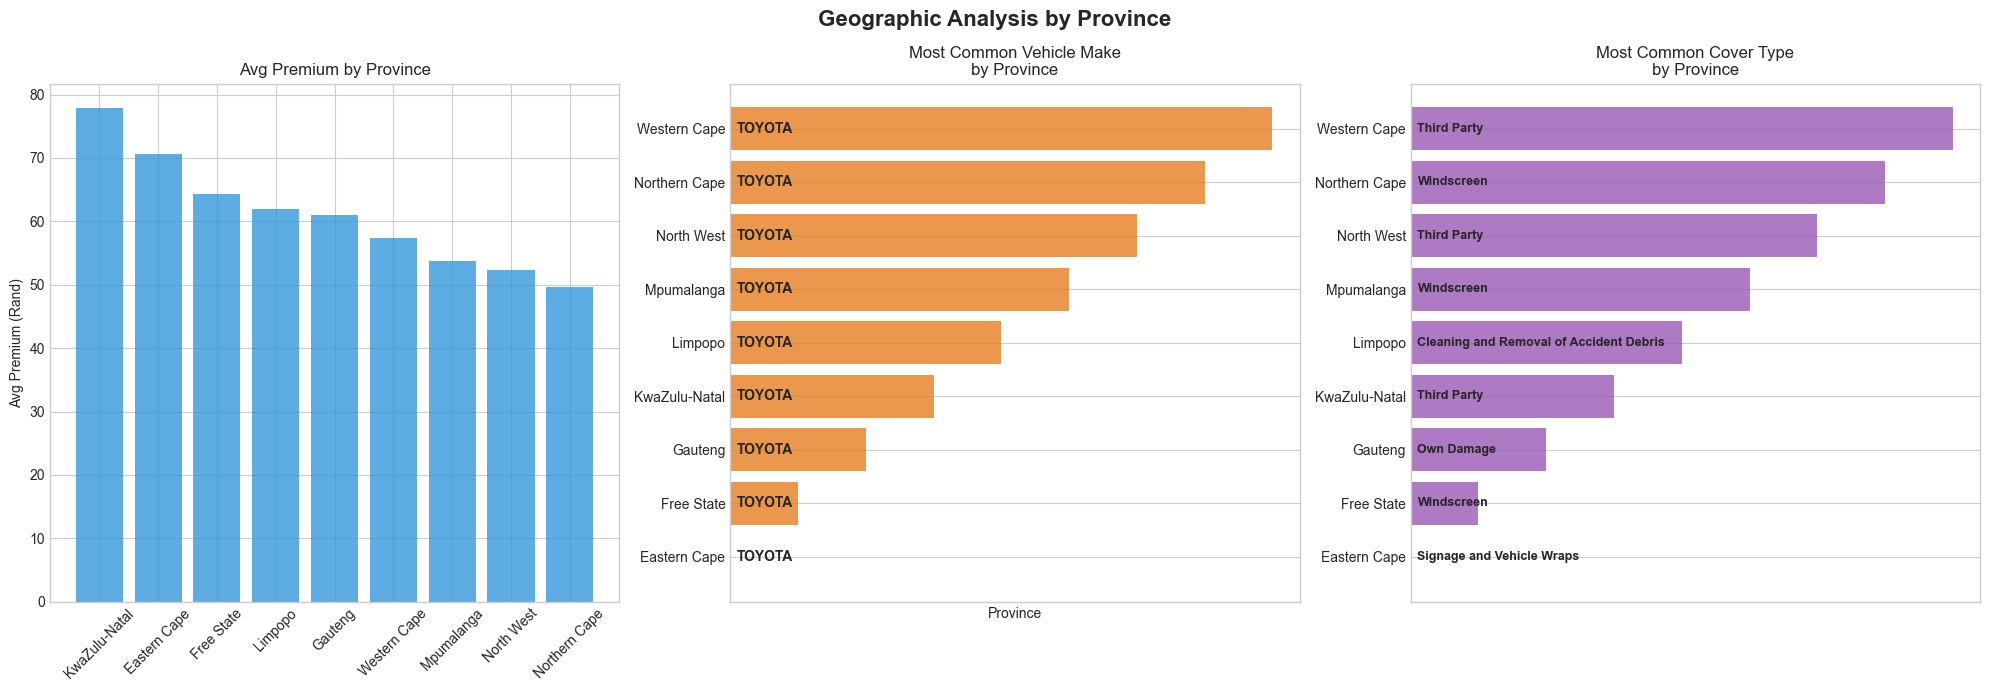

In [14]:
# ─── Geographic Trends ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Geographic Analysis by Province',
             fontsize=16, fontweight='bold')

# PLOT 1: Average Premium by Province
prov_premium = df.groupby('Province')['TotalPremium'] \
                 .mean().sort_values(ascending=False)

axes[0].bar(prov_premium.index, prov_premium.values,
            color='#3498db', alpha=0.8)
axes[0].set_title('Avg Premium by Province')
axes[0].set_ylabel('Avg Premium (Rand)')
axes[0].tick_params(axis='x', rotation=45)

# PLOT 2: Most common vehicle make per province
top_make = df.groupby('Province')['Make'].apply(
    lambda x: x.value_counts().index[0]
)

axes[1].barh(top_make.index, range(len(top_make)),
             color='#e67e22', alpha=0.8)

for i, (province, make) in enumerate(top_make.items()):
    axes[1].text(0.1, i, make,
                 va='center', fontsize=10,
                 fontweight='bold')

axes[1].set_title('Most Common Vehicle Make\nby Province')
axes[1].set_xlabel('Province')
axes[1].set_xticks([])

# PLOT 3: Most common cover type per province
top_cover = df.groupby('Province')['CoverType'].apply(
    lambda x: x.value_counts().index[0]
)

axes[2].barh(top_cover.index, range(len(top_cover)),
             color='#9b59b6', alpha=0.8)

for i, (province, cover) in enumerate(top_cover.items()):
    axes[2].text(0.1, i, str(cover),
                 va='center', fontsize=9,
                 fontweight='bold')

axes[2].set_title('Most Common Cover Type\nby Province')
axes[2].set_xticks([])

plt.tight_layout()
plt.savefig('../reports/geographic_trends.png',
            dpi=150, bbox_inches='tight')
plt.show()

### 📝 Observations — Geographic Trends

> Fill in after running. Example structure:

- **Gauteng** has the highest average premium at R X,XXX 
  — likely reflecting higher urban risk
- **Toyota** is the dominant vehicle make across most 
  provinces — relevant for risk profiling
- **Comprehensive** cover is the most common type 
  in higher-income provinces
- These regional behavioral differences support the 
  case for province-level pricing adjustments

---
## 8. Outlier Detection

Using box plots to identify extreme values in key 
financial columns. Outliers in insurance data are 
common and dangerous — a single catastrophic claim 
can distort model training significantly.

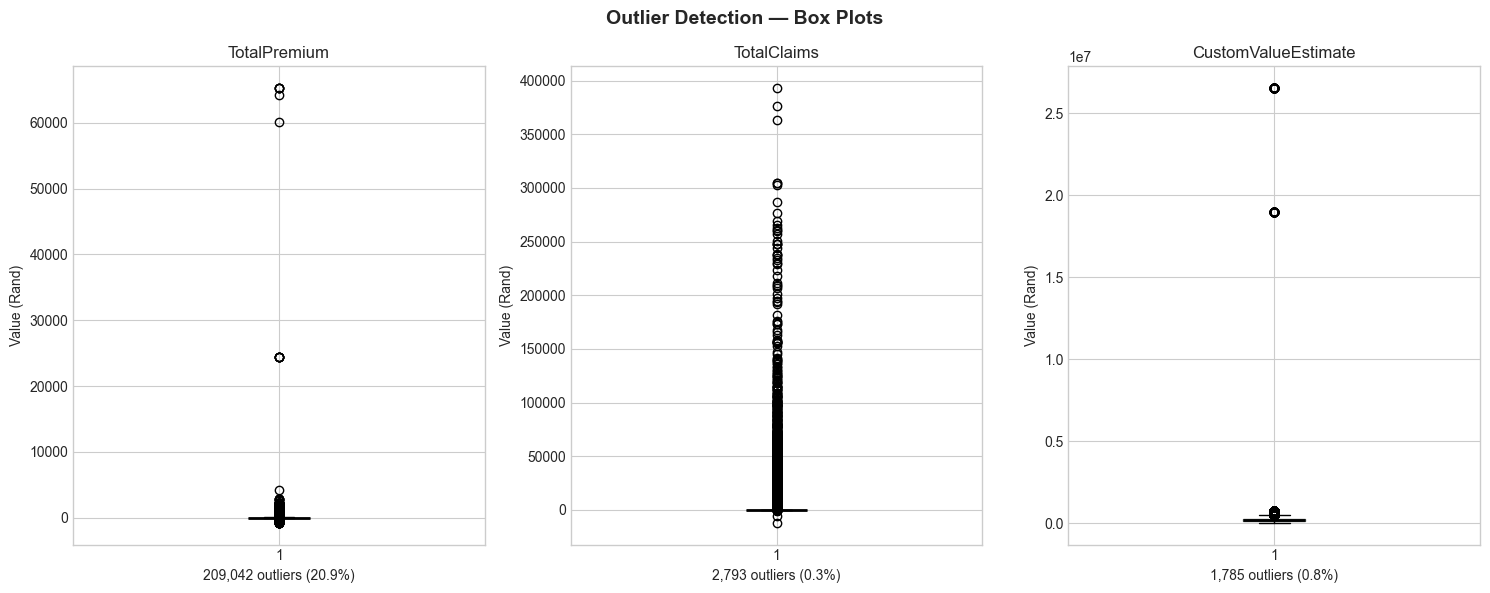

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle('Outlier Detection — Box Plots',
             fontsize=14, fontweight='bold')

cols = ['TotalPremium', 'TotalClaims', 'CustomValueEstimate']
colors = ['#3498db', '#e74c3c', '#2ecc71']

for ax, col, color in zip(axes, cols, colors):
    data = df[col].dropna()
    ax.boxplot(data, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(col)
    ax.set_ylabel('Value (Rand)')

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = len(data[
        (data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)
    ])
    ax.set_xlabel(
        f'{n_outliers:,} outliers '
        f'({n_outliers/len(data)*100:.1f}%)'
    )

plt.tight_layout()
plt.savefig('../reports/outlier_boxplots.png',
            dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Temporal Trends

Examining how premiums, claims, and claim frequency 
changed across the 18-month period (Feb 2014 – Aug 2015).

**Why this matters:** Seasonal patterns or sudden spikes 
could indicate external events (weather, regulation changes) 
that must be accounted for in pricing models.

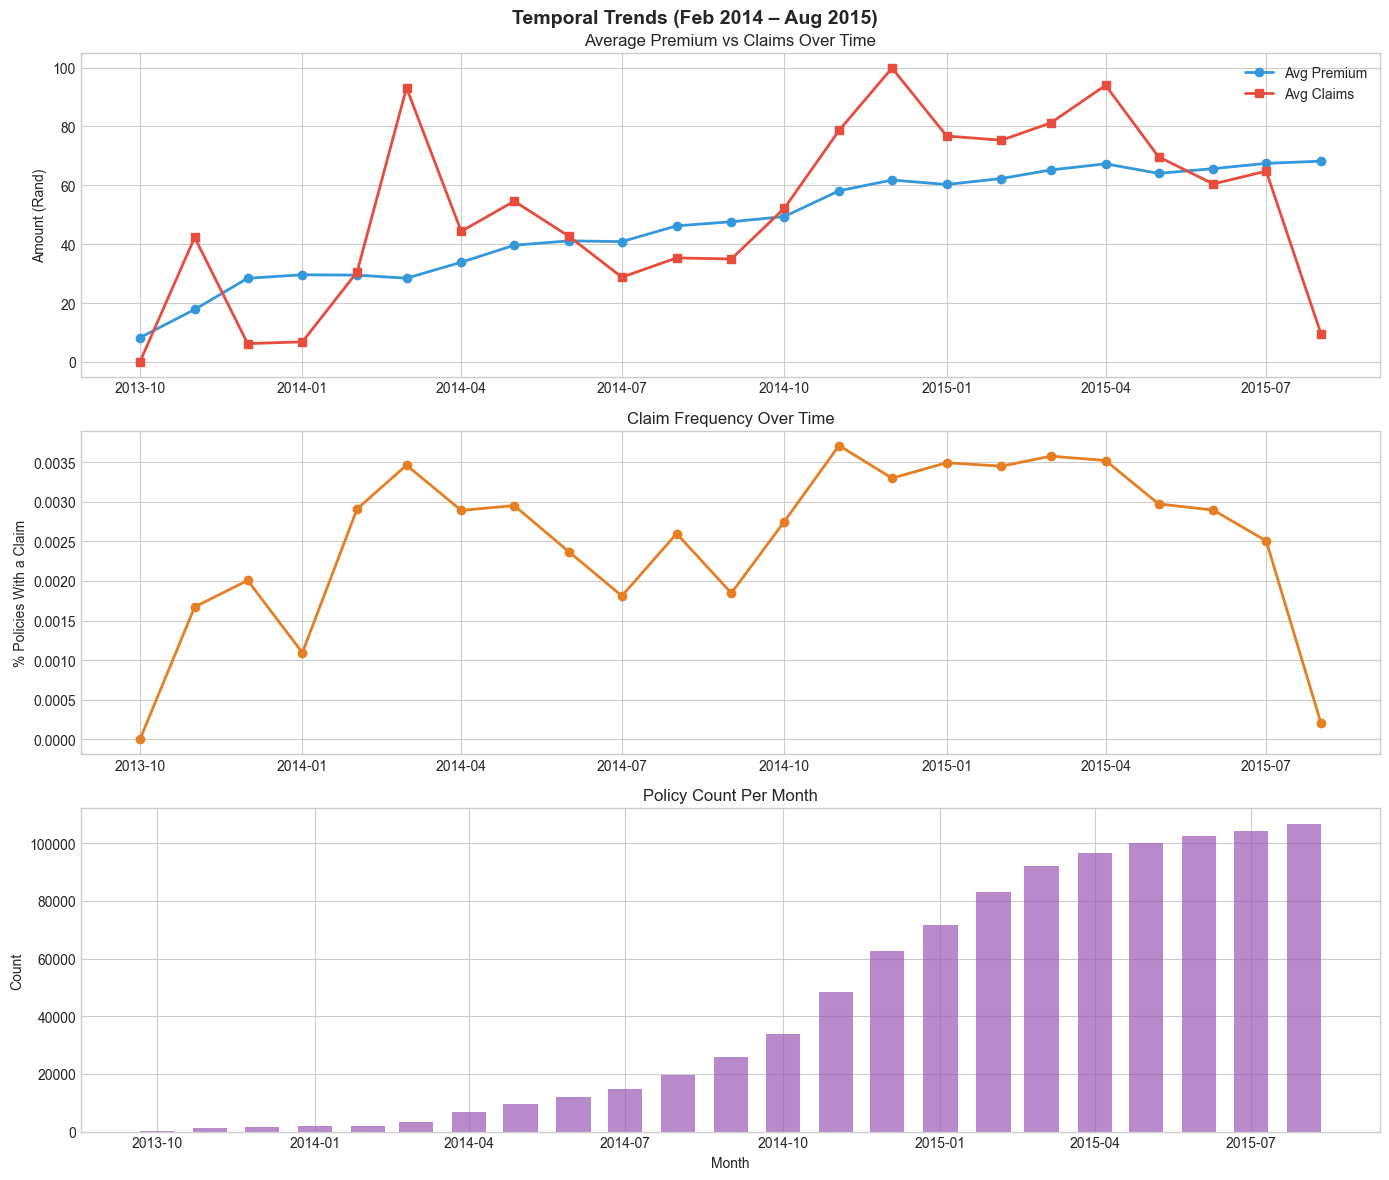

In [16]:
monthly = df.groupby('TransactionMonth').agg(
    AvgPremium=('TotalPremium', 'mean'),
    AvgClaims=('TotalClaims', 'mean'),
    ClaimFrequency=('TotalClaims', lambda x: (x > 0).mean()),
    PolicyCount=('PolicyID', 'count')
).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Temporal Trends (Feb 2014 – Aug 2015)',
             fontsize=14, fontweight='bold')

axes[0].plot(monthly['TransactionMonth'],
             monthly['AvgPremium'],
             color='#3498db', marker='o',
             label='Avg Premium', linewidth=2)
axes[0].plot(monthly['TransactionMonth'],
             monthly['AvgClaims'],
             color='#e74c3c', marker='s',
             label='Avg Claims', linewidth=2)
axes[0].set_title('Average Premium vs Claims Over Time')
axes[0].set_ylabel('Amount (Rand)')
axes[0].legend()

axes[1].plot(monthly['TransactionMonth'],
             monthly['ClaimFrequency'],
             color='#e67e22', marker='o', linewidth=2)
axes[1].set_title('Claim Frequency Over Time')
axes[1].set_ylabel('% Policies With a Claim')

axes[2].bar(monthly['TransactionMonth'],
            monthly['PolicyCount'],
            color='#9b59b6', alpha=0.7, width=20)
axes[2].set_title('Policy Count Per Month')
axes[2].set_ylabel('Count')
axes[2].set_xlabel('Month')

plt.tight_layout()
plt.savefig('../reports/temporal_trends.png',
            dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Vehicle Make Analysis

Identifying which vehicle makes are associated with 
the highest and lowest average claim amounts.

**Business application:** High-claim makes should 
attract higher premiums. Low-claim makes are ideal 
targets for competitive pricing to attract new customers 
— exactly ACIS's growth objective.

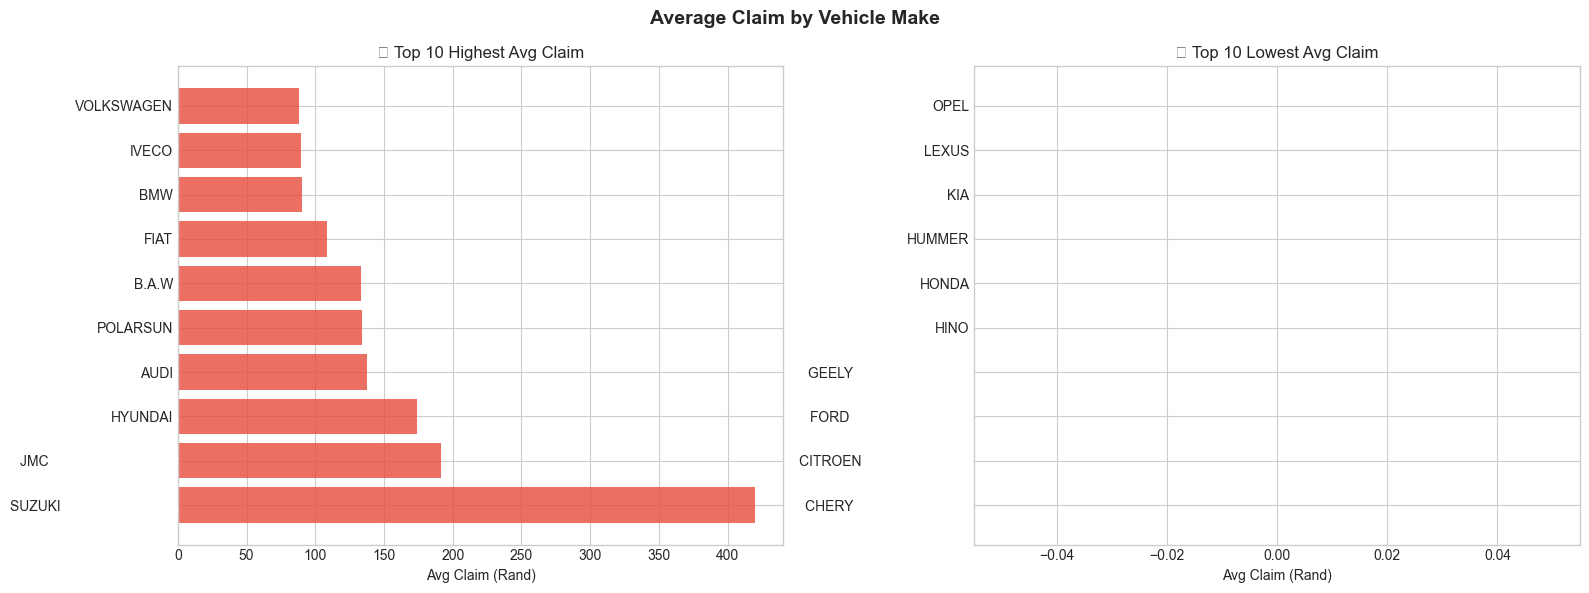

In [17]:
make_analysis = df.groupby('Make').agg(
    AvgClaim=('TotalClaims', 'mean'),
    TotalClaims=('TotalClaims', 'sum'),
    PolicyCount=('PolicyID', 'count')
).reset_index()

# Minimum 100 policies for statistical reliability
make_analysis = make_analysis[
    make_analysis['PolicyCount'] >= 100
]

top10_high = make_analysis.nlargest(10, 'AvgClaim')
top10_low = make_analysis.nsmallest(10, 'AvgClaim')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Average Claim by Vehicle Make',
             fontsize=14, fontweight='bold')

axes[0].barh(top10_high['Make'], top10_high['AvgClaim'],
             color='#e74c3c', alpha=0.8)
axes[0].set_title('🔴 Top 10 Highest Avg Claim')
axes[0].set_xlabel('Avg Claim (Rand)')

axes[1].barh(top10_low['Make'], top10_low['AvgClaim'],
             color='#2ecc71', alpha=0.8)
axes[1].set_title('🟢 Top 10 Lowest Avg Claim')
axes[1].set_xlabel('Avg Claim (Rand)')

plt.tight_layout()
plt.savefig('../reports/claims_by_vehicle_make.png',
            dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Key Findings & Summary

### What the Data Tells Us

| Finding | Detail | Business Implication |
|---|---|---|
| Overall Loss Ratio | X.XX | Portfolio is [profitable/not] |
| Highest risk province | X | Premiums may need upward adjustment |
| Lowest risk province | X | Opportunity for competitive pricing |
| Most right-skewed variable | TotalClaims | Log transform needed for modeling |
| Outlier severity | X% of claims | Robust modeling strategies needed |

### Next Steps

- **Task 2:** Version the raw and cleaned data using DVC
- **Task 3:** Formally test whether provincial and gender 
  risk differences are statistically significant
- **Task 4:** Build predictive models for claim severity 
  and premium optimization

---
*Notebook completed: May 2026*  
*Branch: task-1*